<div dir="rtl" style="text-align: right; line-height: 1.9; font-family: 'Segoe UI', Tahoma, Arial, sans-serif; font-size: 16px;">

**[🡨 بازگشت به فصل چهارم (شبیه‌سازی مونت‌کارلو)](Fasl_4_Masterclass.ipynb)**

# 🎓 مسترکلاس مهندسی مالی تصادفی با پایتون
## فصل ۵: فرآیندهای تصادفی (Stochastic Processes & Brownian Motion)

---
### 🎯 هدف این نوت‌بوک
در فصل قبل یاد گرفتیم که چگونه متغیرهای تصادفی تولید کنیم. در این فصل، مفهوم «زمان» را به متغیرهای تصادفی اضافه می‌کنیم. یک **فرآیند تصادفی (Stochastic Process)** مجموعه‌ای از متغیرهای تصادفی است که در طول زمان ایندکس شده‌اند: $\{X_t\}_{t \ge 0}$.

در این مسترکلاس، مفاهیم زیر را به صورت شی‌گرا و ریاضیاتی کالبدشکافی می‌کنیم:
1. **قدم‌زدن تصادفی متقارن (Symmetric Random Walk):** پایه و اساس رفتار بازارهای مالی در زمان گسسته.
2. **قضیه دانسکر (Donsker's Theorem):** چگونه با فشرده‌سازی زمان، قدم‌زدن تصادفی به حرکت براونی پیوسته تبدیل می‌شود.
3. **حرکت براونی و پیش‌بینی (Brownian Motion):** مدل‌سازی قیمت دارایی‌ها با دریفت ($\mu$) و نوسانات ($\sigma$).
4. **فرآیند پواسون (Poisson Process):** مدل‌سازی رخدادهای گسسته مانند شوک‌ها و سقوط‌های ناگهانی بازار.

</div>

In [ ]:
# نصب و بارگذاری کتابخانه‌های مورد نیاز
!pip install scipy numpy pandas matplotlib seaborn

import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, poisson
from abc import ABC, abstractmethod
from dataclasses import dataclass
from matplotlib.ticker import FormatStrFormatter

plt.style.use("seaborn-v0_8-darkgrid")
print("\n--- محیط محاسباتی با موفقیت راه‌اندازی شد. ---")


--- محیط محاسباتی با موفقیت راه‌اندازی شد. ---


<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۱: قدم‌زدن تصادفی متقارن و مقیاس‌بندی آن (Scaled Random Walk)

مدل **قدم‌زدن تصادفی (Random Walk)** فرض می‌کند که در هر گام زمانی، قیمت سهام می‌تواند با احتمال مساوی (۵۰٪) یک واحد بالا (+$1$) یا یک واحد پایین (-$1$) برود.

$$S_n = \sum_{i=1}^n X_i \quad , \quad P(X_i = 1) = 0.5 \, , \, P(X_i = -1) = 0.5$$

طبق **قضیه دانسکر (اصل عدم تغییر)**، اگر ما تعداد گام‌ها را بسیار کوچک ($\Delta t \to 0$) و اندازه حرکت‌ها را متناسب با جذر زمان ($\sqrt{\Delta t}$) مقیاس‌بندی کنیم، این فرآیند گسسته به یک فرآیند پیوسته به نام **حرکت براونی استاندارد (Standard Brownian Motion)** همگرا می‌شود.

$$W_t^{(n)} = \frac{1}{\sqrt{n}} S_{nt} \xrightarrow{n \to \infty} W_t$$

در کد زیر، یک قدم‌زدن تصادفی گسسته تولید کرده و سپس آن را در طول زمان مقیاس‌بندی (Scale و Interpolate) می‌کنیم.

</div>

شبیه‌سازی قدم‌زدن تصادفی متقارن و همگرایی به حرکت براونی:


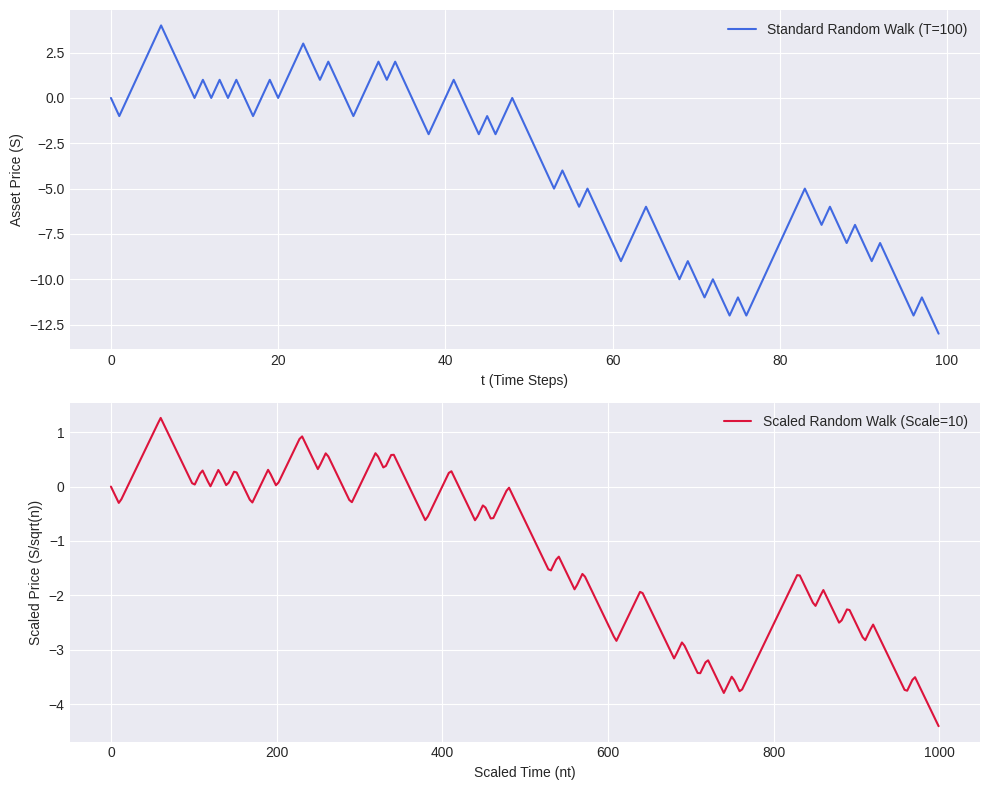

In [ ]:
# --- 1. Scaled Symmetric Random Walk ---
class ScaledSymmetricRandomWalkModel:
    UP_MOVE = 1
    DOWN_MOVE = -1

    def __init__(self, scale_factor: int, total_time):
        self.scale_factor = scale_factor
        self.T = total_time
        self.scaled_delta_t = math.sqrt(float(self.T / self.scale_factor))

    def __compute_initial_walk__(self):
        # Simulate a standard discrete random walk
        s = np.zeros(self.T + 1)
        for t in range(1, self.T + 1):
            prob = random.random()
            move = self.UP_MOVE if prob >= 0.5 else self.DOWN_MOVE
            s[t] = s[t-1] + move
        return s

    def __interpolate_step__(self, walk, n_t, sq_root_scale_factor):
        # Linear interpolation for fractional time steps
        t = float(n_t / self.scale_factor)
        t_upper, t_lower = int(math.ceil(t)), int(math.floor(t))
        s_t_upper = walk[t_upper] / sq_root_scale_factor
        s_t_lower = walk[t_lower] / sq_root_scale_factor
        return float(s_t_lower + float((((t - t_lower) / (t_upper - t_lower)) * (s_t_upper - s_t_lower))))

    def __compute_scaled_walk__(self, initial_walk):
        # Scale the walk by 1/sqrt(n)
        scaled_walk = []
        n_t = 0.0
        sq_root_scale_factor = math.sqrt(self.scale_factor)
        while n_t <= (self.T * self.scale_factor):
            if n_t.is_integer():
                scaled_s = float(initial_walk[int(math.floor(n_t))] / sq_root_scale_factor)
            else:
                scaled_s = self.__interpolate_step__(initial_walk, n_t, sq_root_scale_factor)
            scaled_walk.append({'t': n_t, 'S': scaled_s})
            n_t += self.scaled_delta_t
        return pd.DataFrame(scaled_walk)

    def plot_scaled_walk(self):
        initial_walk = self.__compute_initial_walk__()
        scaled_walk = self.__compute_scaled_walk__(initial_walk)

        fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))
        ax[0].plot(initial_walk[:self.T], color='royalblue', label=f'Standard Random Walk (T={self.T})')
        ax[0].set_xlabel('t (Time Steps)')
        ax[0].set_ylabel('Asset Price (S)')
        ax[0].legend()

        ax[1].plot(scaled_walk['t'], scaled_walk['S'], color='crimson',
                   label=f'Scaled Random Walk (Scale={self.scale_factor})')
        ax[1].set_xlabel('Scaled Time (nt)')
        ax[1].set_ylabel('Scaled Price (S/sqrt(n))')
        ax[1].legend()
        plt.tight_layout()
        plt.show()

# اجرای شبیه‌سازی قدم‌زدن تصادفی
print("شبیه‌سازی قدم‌زدن تصادفی متقارن و همگرایی به حرکت براونی:")
model = ScaledSymmetricRandomWalkModel(scale_factor=10, total_time=100)
model.plot_scaled_walk()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۲: موتور پیش‌بینی با شبیه‌سازی مونت‌کارلو

برای شبیه‌سازی مسیرهای آینده قیمت سهام، ما باید از یک «توزیع هدف» نمونه‌برداری کنیم. در اینجا برای حرکت براونی، در هر گام زمانی یک متغیر تصادفی نرمال استاندارد $Z \sim \mathcal{N}(0,1)$ نیاز داریم.

در این بخش از کدهایی که در فصل ۴ برای موتور Monte Carlo نوشتیم به عنوان زیرساخت استفاده می‌کنیم (برای استقلال این فایل، حداقل کدهای مورد نیاز در اینجا به صورت کپسوله وارد شده‌اند).

</div>

In [ ]:
from typing import List

# --- 2. Base Forecasting & Monte Carlo Engine (Zero-Dependency Setup) ---

class TargetSamplingDensity(ABC):
    @abstractmethod
    def pdf(self, x): ...
    @abstractmethod
    def sample(self, n_vars, n_sample_paths=1): ...

class StandardNormalTargetSamplingDensity(TargetSamplingDensity):
    def pdf(self, x): return norm.pdf(x)
    def sample(self, n_vars, n_sample_paths=1): return norm().rvs(size=(n_sample_paths, n_vars))

class VarReduction(ABC):
    @abstractmethod
    def sample_H_x(self, x=None): ...

class NoVarReduction(VarReduction):
    def __init__(self):
        self._h_x_fun = None
    def sample_H_x(self, x=None):
        # Applies the path generation function sequentially to the random variables
        H_x = np.vectorize(lambda y: self._h_x_fun(y), otypes=[float])
        return H_x(x)

class MonteCarloSimulation:
    @dataclass
    class MCEstimate:
        samples: List = None
        mean: np.ndarray = None
        standard_error: np.ndarray = None

    def __init__(self, h_x_fun: callable, target_sampling_density: TargetSamplingDensity,
                 n_vars: int, n_sample_paths: int=1, var_reduction: VarReduction = NoVarReduction()):
        self._h_x_fun = h_x_fun
        self._n_vars = n_vars
        self._n_sample_paths = n_sample_paths
        self._target_sampling_desnity = target_sampling_density
        self._var_reduction = var_reduction
        self._var_reduction._h_x_fun = h_x_fun

    def new_estimate(self):
        x = self._target_sampling_desnity.sample(n_vars=self._n_vars, n_sample_paths=self._n_sample_paths)
        estimate = self.MCEstimate()
        estimate.samples = self._var_reduction.sample_H_x(x)
        # Calculate mean across paths for each time step
        estimate.mean = np.average(estimate.samples, axis=0)
        variance = np.sum(np.power(estimate.samples - estimate.mean, 2), axis=0) / (self._n_sample_paths - 1 + 1e-10)
        estimate.standard_error = np.sqrt(variance / self._n_sample_paths)
        return estimate

# Base Forecasting Process
class ForecastingProcess(ABC):
    def __init__(self, n_sample_paths, initial_state, sampling_density: TargetSamplingDensity):
        self._n_sample_paths = n_sample_paths
        self._t, self._T = 0, 0
        self._state_t = initial_state
        self._initial_state = initial_state
        self._sampling_density = sampling_density

    def forecast(self, T, var_reduction: VarReduction = NoVarReduction()):
        self._T = T
        self._t = 0
        mcs = MonteCarloSimulation(h_x_fun=self._update_current_state, n_vars=T,
                                   n_sample_paths=self._n_sample_paths,
                                   var_reduction=var_reduction, target_sampling_density=self._sampling_density)
        e = mcs.new_estimate()
        self._state_t = self._initial_state
        return e

    @abstractmethod
    def _update_current_state(self, z): ...

    def _reset_new_sample_path_state(self):
        if self._t >= self._T:
            self._state_t = self._initial_state
            self._t = 0
        self._t += 1

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۳: فرآیند حرکت براونی (Brownian Motion Process)

حرکت براونی یک فرآیند پیوسته است. وقتی آن را برای قیمت سهام (به همراه یک روند نزولی یا صعودی ثابت) اعمال می‌کنیم، به معادله زیر می‌رسیم:
$$X_t = X_{t-1} + \mu + \sigma Z_t$$

که در آن $\mu$ نرخ رانش (Drift)، $\sigma$ نوسان‌پذیری (Volatility) و $Z_t$ نموهای استاندارد نرمال هستند.
ما خروجی را با کلاس `ForecastResultDisplay` شامل مسیرهای شبیه‌سازی‌شده (Sample Paths)، میانگین امید ریاضی (Mean Path) و کران‌های عدم قطعیت (Uncertainty Bounds) مصورسازی می‌کنیم.

</div>

شبیه‌سازی حرکت براونی با دریفت مثبت (μ=10) و نوسان (σ=50) برای ۳۰ مسیر احتمالی:


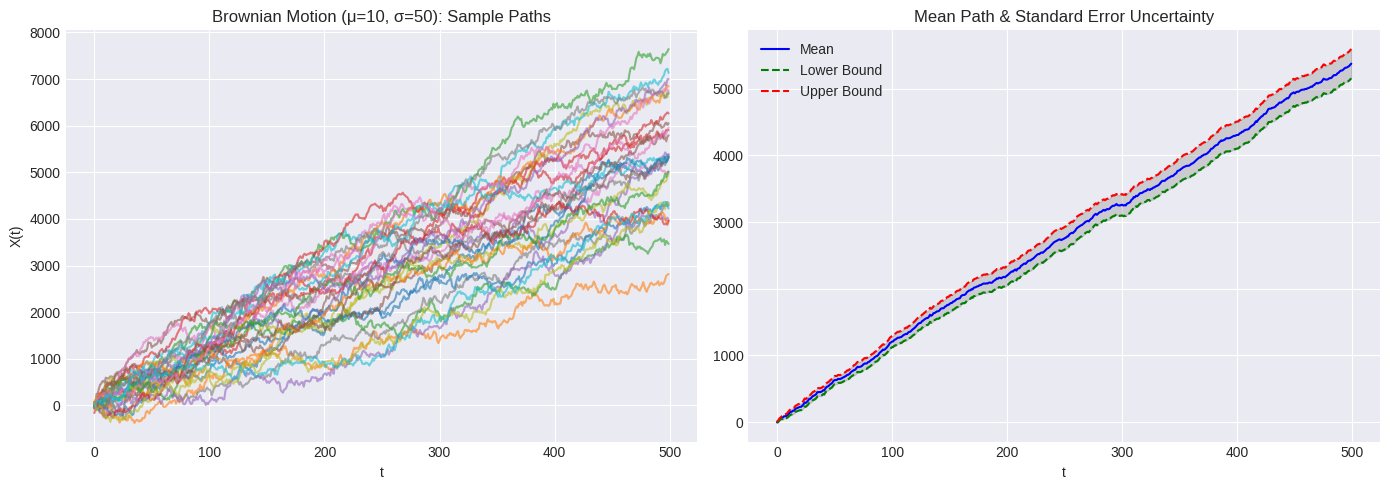

In [ ]:
# --- 3. Brownian Motion Process ---
class BrownianMotionProcess(ForecastingProcess):
    def __init__(self, μ, σ, initial_state=0, n_sample_paths=5):
        super().__init__(initial_state=initial_state, n_sample_paths=n_sample_paths,
                         sampling_density=StandardNormalTargetSamplingDensity())
        self._μ = μ
        self._σ = σ

    def _update_current_state(self, z):
        self._reset_new_sample_path_state()
        # X_t = X_{t-1} + μ + σ * Z
        self._state_t = self._state_t + self._μ + (self._σ * z)
        return self._state_t

# Visualization Engine
class ForecastResultDisplay:
    def __init__(self, mcs_estimate, xlabel='t', ylabel='X(t)'):
        self._samples = pd.DataFrame(mcs_estimate.samples).transpose()
        self._mean = pd.DataFrame(mcs_estimate.mean)
        self._lb = pd.DataFrame(mcs_estimate.mean - mcs_estimate.standard_error)
        self._ub = pd.DataFrame(mcs_estimate.mean + mcs_estimate.standard_error)
        self._xlabel = xlabel
        self._ylabel = ylabel

    def plot_all(self, title="Stochastic Process Forecast"):
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Plot Sample Paths
        self._samples.plot(ax=ax[0], alpha=0.6, legend=False)
        ax[0].set_title(f"{title}: Sample Paths")
        ax[0].set_xlabel(self._xlabel)
        ax[0].set_ylabel(self._ylabel)

        # Plot Mean and Uncertainty
        self._mean.plot(ax=ax[1], color='blue', label='Expected Mean Path')
        self._lb.plot(ax=ax[1], color='green', linestyle='--', label='Lower Bound')
        self._ub.plot(ax=ax[1], color='red', linestyle='--', label='Upper Bound')
        ax[1].fill_between(self._mean.index, self._lb[0], self._ub[0], color='grey', alpha=0.3)
        ax[1].set_title("Mean Path & Standard Error Uncertainty")
        ax[1].set_xlabel(self._xlabel)
        ax[1].legend(['Mean', 'Lower Bound', 'Upper Bound'])

        plt.tight_layout()
        plt.show()

print("شبیه‌سازی حرکت براونی با دریفت مثبت (μ=10) و نوسان (σ=50) برای ۳۰ مسیر احتمالی:")
bmp = BrownianMotionProcess(μ=10, σ=50, n_sample_paths=30)
result_bm = bmp.forecast(T=500)
display_bm = ForecastResultDisplay(result_bm)
display_bm.plot_all("Brownian Motion (μ=10, σ=50)")

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

### 📚 بخش ۴: فرآیند پواسون (Poisson Process)

فرآیند پواسون برای مدل‌سازی رویدادهای گسسته در زمان پیوسته (مثل تعداد ورشکستگی‌ها، تعداد پرش‌های ناگهانی قیمت، یا رسیدن سفارشات به یک صرافی) استفاده می‌شود.

$$P(N(t+\Delta t) - N(t) = k) = \frac{e^{-\lambda \Delta t}(\lambda \Delta t)^k}{k!}$$

در اینجا، متغیر تصادفی نموها، از توزیع پواسون با نرخ $\lambda$ استخراج می‌شود. هرچه $\lambda$ بزرگتر باشد، شدت پرش‌ها در واحد زمان بیشتر است.

</div>

شبیه‌سازی فرآیند پواسون با شدت‌های مختلف (λ متفاوت):


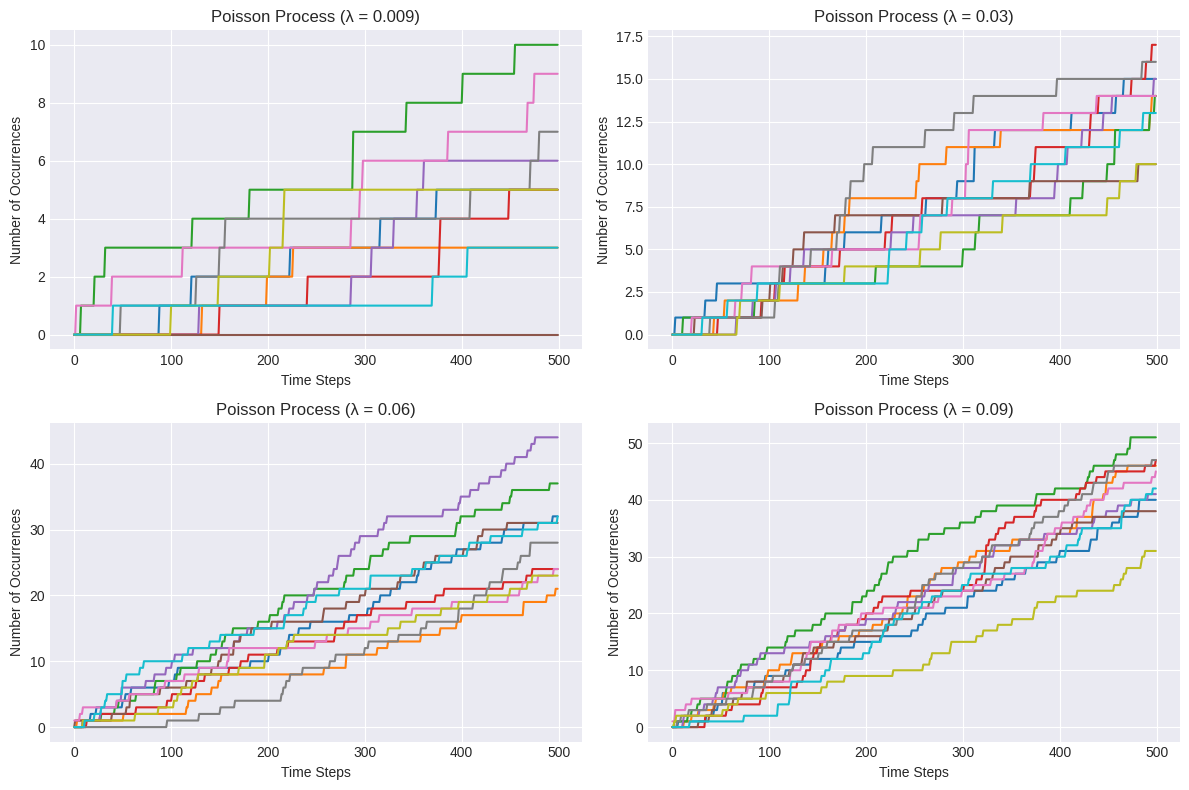

In [ ]:
# --- 4. Poisson Process ---
class PoissonTargetSamplingDensity(TargetSamplingDensity):
    def __init__(self, λ):
        self._λ = λ
    def pdf(self, x): return poisson(self._λ).pmf(x)
    def sample(self, n_vars, n_sample_paths=1):
        return poisson.rvs(self._λ, size=(n_sample_paths, n_vars))

class PoissonProcess(ForecastingProcess):
    def __init__(self, λ, initial_state=0, n_sample_paths=5):
        super().__init__(initial_state=initial_state, n_sample_paths=n_sample_paths,
                         sampling_density=PoissonTargetSamplingDensity(λ=λ))
        self._λ = λ

    def _update_current_state(self, z):
        self._reset_new_sample_path_state()
        # N_t = N_{t-1} + ΔN
        self._state_t = self._state_t + z
        return self._state_t

print("شبیه‌سازی فرآیند پواسون با شدت‌های مختلف (λ متفاوت):")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
lambdas = [(0.009, axes[0,0]), (0.03, axes[0,1]), (0.06, axes[1,0]), (0.09, axes[1,1])]

for lam, ax in lambdas:
    pp = PoissonProcess(λ=lam, n_sample_paths=10)
    res_pp = pp.forecast(T=500)
    samples_df = pd.DataFrame(res_pp.samples).transpose()
    samples_df.plot(ax=ax, legend=False)
    ax.set_title(f"Poisson Process (λ = {lam})")
    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Number of Occurrences")

plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; line-height: 1.9; font-size: 16px;">

---
### 🏁 نتیجه‌گیری فصل ۵
در این فصل ما توانستیم زمان را وارد معادلات تصادفی خود کنیم:
1. دیدیم که قدم‌زدن تصادفیِ ساده، با مقیاس‌بندی صحیح، مبنای ساخت **حرکت براونی** است.
2. چارچوبی شی‌گرا برای پیش‌بینی (Forecasting) طراحی کردیم که به ما اجازه داد رفتار آینده بازار را با کران‌های عدم‌قطعیت ترسیم کنیم.
3. با **فرآیند پواسون** آشنا شدیم که در فصل ۷ برای خلق «مدل‌های پرش-دیفیوژن» (Jump-Diffusion Models) با حرکت براونی ترکیب خواهد شد.

در فصل ۶، این فرآیندها را وارد **معادلات دیفرانسیل تصادفی (SDEs)** نظیر معادله حرکت براونی هندسی (GBM) خواهیم کرد که فرمول اصلی قیمت‌گذاری مشتقات مالی را شکل می‌دهد.

</div>